In [1]:
from typing_extensions import TypedDict, Literal, Annotated
from langgraph.types import Send
from langgraph.graph import StateGraph, START, END
from langchain.chat_models import init_chat_model
from operator import add

llm = init_chat_model("openai:gpt-5-nano")

In [2]:
class State(TypedDict):

    document: str
    final_summary: str
    summaries: Annotated[list[dict], add]

In [3]:
def summarize_p(args):
    paragraph = args["paragraph"]
    index = args["index"]
    response = llm.invoke(
        f"이 단락을 3문장으로 요약하세요: {paragraph}",
    )
    return {
        "summaries": [
            {
                "summary": response.content,
                "index": index,
            }
        ],
    }


def dispatch_summarizers(state: State):
    chunks = state["document"].split("\n\n")
    return [
        Send("summarize_p", {"paragraph": chunk, "index": idx})
        for idx, chunk in enumerate(chunks)
    ]  # parallel


def final_summary(state: State):
    response = llm.invoke(
        f"제공된 요약본들을 활용해 최종 요약본 하나를 작성하세요. {state["summaries"]}"
    )
    return {"final_summary": response.content}

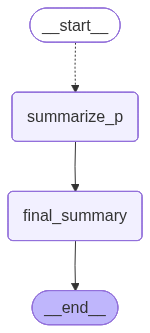

In [4]:
graph_builder = StateGraph(State)

graph_builder.add_node("summarize_p", summarize_p)
graph_builder.add_node("final_summary", final_summary)

graph_builder.add_conditional_edges(START, dispatch_summarizers, ["summarize_p"])
graph_builder.add_edge("summarize_p", "final_summary")
graph_builder.add_edge("final_summary", END)

graph = graph_builder.compile()

graph

In [5]:
with open("fed_transcript.md", "r", encoding="utf-8") as f:
    document = f.read()

for chunk in graph.stream(
    {"document": document},
    stream_mode="updates",
):
    print(chunk, "\n")

{'summarize_p': {'summaries': [{'summary': '주택 부문 활동은 여전히 약세를 보입니다.  \n경제 전망 요약에 따르면 중앙값 참가자는 올해 GDP가 1.6%, 내년에는 1.8% 증가할 것으로 전망합니다.  \n이는 6월 전망보다 다소 강한 수치입니다.', 'index': 4}]}} 

{'summarize_p': {'summaries': [{'summary': '최근 지표들에 따르면 경제 활동의 성장세가 둔화되고 있다. 올해 상반기에 GEP는 약 1.5%의 속도로 상승했다. 이는 작년의 2.5%에서 감소한 것이다.', 'index': 1}]}} 

{'summarize_p': {'summaries': [{'summary': '8월에 실업률이 소폭 상승해 4.3%를 기록했다.  \n하지만 지난 1년간 큰 변동은 없었다.  \n실업률은 여전히 비교적 낮은 수준에 있다.', 'index': 5}]}} 

{'summarize_p': {'summaries': [{'summary': '우리의 통화 정책은 미국 국민의 최대 고용과 물가 안정을 달성한다는 이중 임무에 따라 움직인다. 이 이중 임무의 핵심 목표는 고용의 최대화와 물가의 안정이다. 따라서 모든 정책 결정은 이 두 목표를 달성하는 방향으로 이루어진다.', 'index': 13}]}} 

{'summarize_p': {'summaries': [{'summary': '이 현상의 완화와 성장은 대부분 소비 지출의 둔화에 의해 설명된다.  \n소비자 지출이 줄어들면서 경제 성장의 속도가 둔화되었다.  \n따라서 현재의 완화 흐름은 소비 부문의 약세를 반영한다.', 'index': 2}]}} 

{'summarize_p': {'summaries': [{'summary': '그럼에도 노동 수요가 약화됐다.  \n최근 고용 창출 속도는 실업률을 일정하게 유지하는 데 필요한 손익분기점 수준보다 낮아 보인다.  \n이로 인해 실업률을 현재 수준으로 유지하기가 어려워질 수 있다.', 'index